<a href="https://colab.research.google.com/github/reedlm11/INFO648/blob/main/Copy_of_Final_Project_Sarah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase 1: Business Understanding**

The U.S. Department of Economic Development wants to allocate funding to areas that are expected to experience population growth. Our objective is to predict which census tracts in the Pacific region will gain population, identify the factors associated with growth, and use those patterns to forecast growth from 2020 to 2030.

Success Criterion

Our goal is to build a classification model that outperforms the majority-class baseline while achieving a strong AUC and balanced precision and recall.

Target Variable

The target variable is whether a census tract gained population between 2010 and 2020. A tract is labeled as "grew" if its population growth is greater than 0%, and "did not grow" otherwise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#**Phase 2: Data Understanding**

Pacific Region

Our analysis focuses on the Pacific Census Division, which includes Alaska, California, Hawaii, Oregon, and Washington. First we'll beging by filtering the national census dataset to include only census tracts from these five states

In [2]:
raw = pd.read_csv("student_tracts_raw.csv")
region_counts = pd.read_csv("region_tract_counts.csv")
data_dict = pd.read_csv("data_dictionary.csv")
forecast = pd.read_csv("forecast_tracts_2020.csv")

pacific_states = ["Alaska", "California", "Hawaii", "Oregon", "Washington"]

pacific = raw[raw["STATE"].isin(pacific_states)].copy()

pacific.shape

(10867, 49)

#Verify the Pacific Region Filter

In [3]:
pacific["STATE"].value_counts()

,count
STATE,
California,8057
Washington,1458
Oregon,834
Hawaii,351
Alaska,167


#Examine Dataset Structure

In [4]:
pacific.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10867 entries, 1181 to 71031
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GISJOIN                  10867 non-null  object 
 1   STATE                    10867 non-null  object 
 2   STATEA                   10867 non-null  int64  
 3   COUNTY                   10867 non-null  object 
 4   COUNTYA                  10867 non-null  int64  
 5   TRACTA                   10867 non-null  int64  
 6   pop_total_2010           10867 non-null  int64  
 7   housing_occupied_2010    10867 non-null  int64  
 8   housing_vacant_2010      10867 non-null  int64  
 9   housing_owner_occ_2010   10867 non-null  int64  
 10  housing_renter_occ_2010  10867 non-null  int64  
 11  age_under5_2010          10867 non-null  int64  
 12  age_5to9_2010            10867 non-null  int64  
 13  age_10to14_2010          10867 non-null  int64  
 14  age_15to17_2010         

In [5]:
pacific.describe().T

,count,mean,std,min,25%,50%,75%,max
STATEA,10867.0,15.221220,17.557049,2.0,6.000000,6.000000,6.000000,53.000000
COUNTYA,10867.0,50.981964,29.173517,1.0,37.000000,51.000000,71.000000,290.000000
TRACTA,10867.0,196604.855894,272777.180289,100.0,8130.500000,42009.000000,360350.000000,992201.000000
pop_total_2010,10867.0,4590.052636,1969.022161,0.0,3324.000000,4403.000000,5658.500000,37452.000000
housing_occupied_2010,10867.0,1603.930063,703.965526,0.0,1128.000000,1527.000000,2006.000000,8382.000000
housing_vacant_2010,10867.0,150.721174,229.025781,0.0,58.000000,96.000000,159.000000,6403.000000
housing_owner_occ_2010,10867.0,927.507408,562.251593,0.0,525.000000,863.000000,1250.000000,5054.000000
housing_renter_occ_2010,10867.0,676.422656,487.686231,0.0,313.000000,572.000000,917.000000,5971.000000
age_under5_2010,10867.0,308.268059,195.894408,0.0,179.000000,276.000000,398.000000,4855.000000
age_5to9_2010,10867.0,304.332198,187.925807,0.0,181.000000,277.000000,393.000000,2639.000000


#Check for Missing Values

In [6]:
pacific.isna().sum().sort_values(ascending=False).head(15)

,0
density_perkm2,65
settlement_type,65
land_area_sqkm,62
STATE,0
COUNTYA,0
TRACTA,0
STATEA,0
COUNTY,0
housing_vacant_2010,0
housing_owner_occ_2010,0


#Initial Observations

- After filtering the national dataset, the Pacific region contains 10,867 census tracts across California, Washington, Oregon, Hawaii, and Alaska.
- The dataset consists primarily of numeric census count variables, with STATE and settlement_type being categorical features.
- Most variables are complete, with missing values only in land_area_sqkm, density_perkm2, and settlement_type. These missing values are consistent with the water-only census tracts described in the project instructions and will be addressed during data prep.
- The summary stats show considerable variation in population, housing, and demographic characteristics across census tracts, suggesting there is meaningful diversity for clustering and classification.

# Phase 3: Data Preparation

In this phase, we prepare the dataset for modeling by creating the target variable, cleaning records with undefined calculations, engineering features, and splitting the data into training and testing sets.

In [7]:
pacific["growth_pct"] = (
    (pacific["pop_total_2020"] - pacific["pop_total_2010"])
    / pacific["pop_total_2010"]
) * 100

pacific["growth_pct"].describe()

,growth_pct
count,1.079700e+04
mean,inf
std,NaN
min,-1.000000e+02
25%,-2.740304e-01
50%,4.321442e+00
75%,9.942085e+00
max,inf


In [8]:
print((pacific["pop_total_2010"] == 0).sum())

84


In [9]:
pacific["pop_total_2010"].describe()

,pop_total_2010
count,10867.000000
mean,4590.052636
std,1969.022161
min,0.000000
25%,3324.000000
50%,4403.000000
75%,5658.500000
max,37452.000000


In [10]:
pacific = pacific[pacific["pop_total_2010"] > 0].copy()

pacific.shape

(10783, 50)

In [11]:
pacific["growth_pct"].describe()

,growth_pct
count,10783.000000
mean,8.167046
std,44.476159
min,-100.000000
25%,-0.280809
50%,4.303123
75%,9.903960
max,2900.000000


In [12]:
pacific["grew"] = (pacific["growth_pct"] > 0).astype(int)

pacific["grew"].value_counts()

,count
grew,
1,7925
0,2858


#Target Variable and Class Balance

The target variable, grew, was created by labeling census tracts with positive population growth between 2010 and 2020 as 1 and tracts with no growth or population loss as 0.

After removing tracts with a 2010 population of zero, the dataset contains 10,783 census tracts. Approximately 73.5% of tracts experienced population growth, while 26.5% did not. Although the classes are not perfectly balanced, both classes are well represented for classification.

In [13]:
pacific[
    pacific["land_area_sqkm"].isna() |
    pacific["density_perkm2"].isna() |
    pacific["settlement_type"].isna()
][["STATE", "COUNTY", "TRACTA", "land_area_sqkm", "density_perkm2", "settlement_type"]].head(10)

,STATE,COUNTY,TRACTA,land_area_sqkm,density_perkm2,settlement_type


In [14]:
pacific[["land_area_sqkm", "density_perkm2", "settlement_type"]].isna().sum()

,0
land_area_sqkm,0
density_perkm2,0
settlement_type,0


#Data Cleaning

To prep the dataset for modeling, we removed census tracts with a 2010 population of zero because population growth could not be calculated for those observations. After removing these tracts, there were no remaining missing values in land_area_sqkm, density_perkm2, or settlement_type. This indicates that the missing values were associated with the zero-population tracts and no additional records needed to be removed.

In [15]:
list(pacific.columns)

['GISJOIN',
 'STATE',
 'STATEA',
 'COUNTY',
 'COUNTYA',
 'TRACTA',
 'pop_total_2010',
 'housing_occupied_2010',
 'housing_vacant_2010',
 'housing_owner_occ_2010',
 'housing_renter_occ_2010',
 'age_under5_2010',
 'age_5to9_2010',
 'age_10to14_2010',
 'age_15to17_2010',
 'age_18to19_2010',
 'age_20_2010',
 'age_21_2010',
 'age_22to24_2010',
 'age_25to29_2010',
 'age_30to34_2010',
 'age_35to39_2010',
 'age_40to44_2010',
 'age_45to49_2010',
 'age_50to54_2010',
 'age_55to59_2010',
 'age_60to61_2010',
 'age_62to64_2010',
 'age_65to69_2010',
 'age_70to74_2010',
 'age_75to79_2010',
 'age_80to84_2010',
 'age_85plus_2010',
 'race_nhwhite_2010',
 'race_nhblack_2010',
 'race_nhaian_2010',
 'race_nhapi_2010',
 'race_nhother_2010',
 'race_nhtwo_2010',
 'race_hispwhite_2010',
 'race_hispblack_2010',
 'race_hispaian_2010',
 'race_hispapi_2010',
 'race_hispother_2010',
 'race_hisptwo_2010',
 'pop_total_2020',
 'land_area_sqkm',
 'density_perkm2',
 'settlement_type',
 'growth_pct',
 'grew']

In [16]:
# Total housing units
pacific["housing_total_2010"] = (
    pacific["housing_occupied_2010"] +
    pacific["housing_vacant_2010"]
)

# Housing percentages
pacific["pct_vacant"] = (
    pacific["housing_vacant_2010"] /
    pacific["housing_total_2010"]
)

pacific["pct_owner_occ"] = (
    pacific["housing_owner_occ_2010"] /
    pacific["housing_total_2010"]
)

pacific["pct_renter_occ"] = (
    pacific["housing_renter_occ_2010"] /
    pacific["housing_total_2010"]
)

pacific[
    [
        "pct_vacant",
        "pct_owner_occ",
        "pct_renter_occ"
    ]
].describe()

,pct_vacant,pct_owner_occ,pct_renter_occ
count,10767.000000,10767.000000,10767.000000
mean,0.080435,0.529870,0.389695
std,0.084046,0.222684,0.214263
min,0.000000,0.000000,0.000000
25%,0.041770,0.370819,0.213046
50%,0.058934,0.555748,0.355915
75%,0.084750,0.707940,0.539597
max,1.000000,1.000000,1.000000


In [17]:
# All age columns
age_cols = [col for col in pacific.columns if col.startswith("age_") and col.endswith("_2010")]

# Convert age counts to percentages of total population
for col in age_cols:
    new_col = col.replace("age_", "pct_age_")
    new_col = new_col.replace("_2010", "")
    pacific[new_col] = pacific[col] / pacific["pop_total_2010"]

# Check a few examples
pacific[
    [
        "pct_age_under5",
        "pct_age_25to29",
        "pct_age_65to69",
        "pct_age_85plus"
    ]
].describe()

,pct_age_under5,pct_age_25to29,pct_age_65to69,pct_age_85plus
count,10783.000000,10783.000000,10783.000000,10783.000000
mean,0.064943,0.073149,0.038189,0.017606
std,0.023544,0.032427,0.019181,0.017287
min,0.000000,0.000000,0.000000,0.000000
25%,0.049312,0.053048,0.025710,0.007659
50%,0.063720,0.070377,0.034743,0.013217
75%,0.079392,0.085458,0.046860,0.021860
max,0.237288,0.400000,0.500000,0.291276


In [18]:
# All race/ethnicity columns
race_cols = [col for col in pacific.columns if col.startswith("race_") and col.endswith("_2010")]

# Convert race counts to percentages of total population
for col in race_cols:
    new_col = col.replace("race_", "pct_race_")
    new_col = new_col.replace("_2010", "")
    pacific[new_col] = pacific[col] / pacific["pop_total_2010"]

# Check a few examples
pacific[
    [
        "pct_race_nhwhite",
        "pct_race_nhblack",
        "pct_race_hispwhite",
        "pct_race_hispother"
    ]
].describe()

,pct_race_nhwhite,pct_race_nhblack,pct_race_hispwhite,pct_race_hispother
count,10783.000000,10783.000000,10783.000000,10783.000000
mean,0.485822,0.050536,0.136593,0.130567
std,0.286967,0.085072,0.120342,0.134192
min,0.000000,0.000000,0.000000,0.000000
25%,0.219486,0.008207,0.044172,0.022456
50%,0.519673,0.020577,0.093040,0.074065
75%,0.745299,0.053081,0.195700,0.212231
max,1.000000,0.897597,1.000000,0.795530


#Feature Engineering

To make the census variables comparable across neighborhoods of different sizes, raw population and housing counts were converted to percentages. Housing variables were divided by the total number of housing units, while age and race/ethnicity variables were divided by the total 2010 population for each census tract. Using percentages instead of raw counts allows the models to compare neighborhood composition rather than differences driven by tract size.

In [19]:
pacific.columns.tolist()

['GISJOIN',
 'STATE',
 'STATEA',
 'COUNTY',
 'COUNTYA',
 'TRACTA',
 'pop_total_2010',
 'housing_occupied_2010',
 'housing_vacant_2010',
 'housing_owner_occ_2010',
 'housing_renter_occ_2010',
 'age_under5_2010',
 'age_5to9_2010',
 'age_10to14_2010',
 'age_15to17_2010',
 'age_18to19_2010',
 'age_20_2010',
 'age_21_2010',
 'age_22to24_2010',
 'age_25to29_2010',
 'age_30to34_2010',
 'age_35to39_2010',
 'age_40to44_2010',
 'age_45to49_2010',
 'age_50to54_2010',
 'age_55to59_2010',
 'age_60to61_2010',
 'age_62to64_2010',
 'age_65to69_2010',
 'age_70to74_2010',
 'age_75to79_2010',
 'age_80to84_2010',
 'age_85plus_2010',
 'race_nhwhite_2010',
 'race_nhblack_2010',
 'race_nhaian_2010',
 'race_nhapi_2010',
 'race_nhother_2010',
 'race_nhtwo_2010',
 'race_hispwhite_2010',
 'race_hispblack_2010',
 'race_hispaian_2010',
 'race_hispapi_2010',
 'race_hispother_2010',
 'race_hisptwo_2010',
 'pop_total_2020',
 'land_area_sqkm',
 'density_perkm2',
 'settlement_type',
 'growth_pct',
 'grew',
 'housing_to

#Summary of Data Preparation

The dataset was cleaned by removing census tracts with a 2010 population of zero, creating the binary target variable, and engineering percentage-based housing, age, and race/ethnicity features. These transformations standardize variables across census tracts of different sizes and prepare the data for classification modeling.

In [20]:
housing_features = [
    "pct_vacant",
    "pct_owner_occ",
    "pct_renter_occ"
]

age_features = [col for col in pacific.columns if col.startswith("pct_age_")]

race_features = [col for col in pacific.columns if col.startswith("pct_race_")]

categorical_features = [
    "STATE",
    "settlement_type"
]

numeric_features = (
    ["land_area_sqkm", "density_perkm2"] +
    housing_features +
    age_features +
    race_features
)

In [21]:
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nCategorical features:")
print(categorical_features)

print("\nFirst 10 numeric features:")
print(numeric_features[:10])

Numeric features: 39
Categorical features: 2

Categorical features:
['STATE', 'settlement_type']

First 10 numeric features:
['land_area_sqkm', 'density_perkm2', 'pct_vacant', 'pct_owner_occ', 'pct_renter_occ', 'pct_age_under5', 'pct_age_5to9', 'pct_age_10to14', 'pct_age_15to17', 'pct_age_18to19']


In [22]:
X = pacific[numeric_features + categorical_features]
y = pacific["grew"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10783, 41)
y shape: (10783,)


#Train-Test Split

The prepared dataset was divided into training (80%) and testing (20%) sets using a stratified random split to preserve the proportion of census tracts that experienced population growth in each dataset. A random state of 42 was used to ensure the results are reproducible.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training feature set: (8626, 41)
Testing feature set: (2157, 41)
Training target: (8626,)
Testing target: (2157,)


# Phase 4: Modeling

## K-Means Clustering

K-means clustering was used to group census tracts into neighborhood types based on their numeric 2010 characteristics. To avoid test leakage, the scaler and K-means model were fit only on the training data, then later applied to the test data.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [25]:
# Scale numeric training features only for clustering
cluster_scaler = StandardScaler()

X_train_numeric_scaled = cluster_scaler.fit_transform(X_train[numeric_features])
X_test_numeric_scaled = cluster_scaler.transform(X_test[numeric_features])

print(X_train_numeric_scaled.shape)
print(X_test_numeric_scaled.shape)

(8626, 39)
(2157, 39)


In [26]:
X_train[numeric_features].isna().sum().sort_values(ascending=False).head(10)

,0
pct_vacant,13
pct_renter_occ,13
pct_owner_occ,13
density_perkm2,0
land_area_sqkm,0
pct_age_under5,0
pct_age_5to9,0
pct_age_10to14,0
pct_age_15to17,0
pct_age_18to19,0


In [27]:
housing_pct_cols = [
    "pct_vacant",
    "pct_owner_occ",
    "pct_renter_occ"
]

X_train[housing_pct_cols] = X_train[housing_pct_cols].fillna(0)
X_test[housing_pct_cols] = X_test[housing_pct_cols].fillna(0)

In [28]:
cluster_scaler = StandardScaler()

X_train_numeric_scaled = cluster_scaler.fit_transform(
    X_train[numeric_features]
)

X_test_numeric_scaled = cluster_scaler.transform(
    X_test[numeric_features]
)

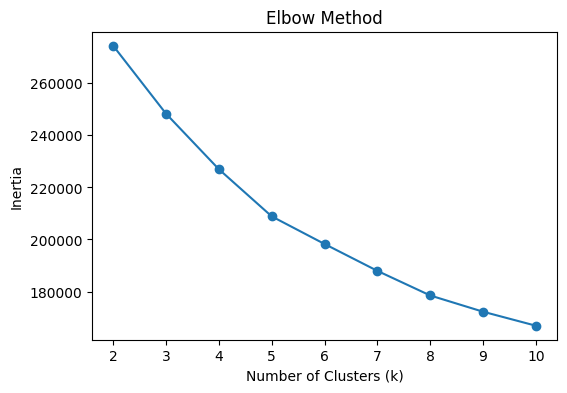

In [29]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_numeric_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [30]:
# Fit final K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_numeric_scaled)
test_clusters = kmeans.predict(X_test_numeric_scaled)

print("Silhouette Score:",
      round(silhouette_score(X_train_numeric_scaled, train_clusters), 3))

Silhouette Score: 0.171


In [31]:
pd.Series(train_clusters).value_counts().sort_index()

,count
0,3307
1,1036
2,108
3,1804
4,2371


#K-Means Results

The elbow method suggested that five clusters provided a reasonable balance between model simplicity and within-cluster variation, so k=5 was selected. The final model produced a silhouette score of 0.171, indicating modest separation between clusters, which is typical for demographic datasets with overlapping characteristics. Most clusters contained a substantial number of census tracts, while one smaller cluster captured a more distinct group of neighborhoods.

In [32]:
X_train["cluster"] = train_clusters
X_test["cluster"] = test_clusters

print(X_train["cluster"].value_counts().sort_index())

cluster
0    3307
1    1036
2     108
3    1804
4    2371
Name: count, dtype: int64


## Phase 5: Evaluation

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

### Model Training with Cluster Feature

In [46]:
# Define feature sets for the full model (with cluster)
numeric_features_model = numeric_features
categorical_features_model = categorical_features + ['cluster']

# Create preprocessors for numeric and categorical features
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_model),
        ('cat', categorical_transformer, categorical_features_model)
    ])

# Create the full model pipeline (Logistic Regression with cluster feature)
model_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Train the full model
model_full.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['land_area_sqkm',
                                                   'density_perkm2',
                                                   'pct_vacant',
                                                   'pct_owner_occ',
                                                   'pct_renter_occ',
                                                   'pct_age_under5',
                                                   'pct_age_5to9',
                                                   'pct_age_10to14',
                                                   'pct_age_15to17',
                                                   'pct_age_18to19',
                                                   'pct_age_20', 'pct_age_21',
                                                   'pct_age_22to24',
                                                   'pct_age_25to29',
                                                   'pct_age_30to34',
                                                   'pct_age_35to39',
                                                   'pct...
                                                   'pct_age_60to61',
                                                   'pct_age_62to64',
                                                   'pct_age_65to69',
                                                   'pct_age_70to74',
                                                   'pct_age_75to79',
                                                   'pct_age_80to84',
                                                   'pct_age_85plus',
                                                   'pct_race_nhwhite',
                                                   'pct_race_nhblack',
                                                   'pct_race_nhaian', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['STATE', 'settlement_type',
                                                   'cluster'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

### Evaluation of the Full Model

Accuracy (Full Model): 0.7714
Precision (Full Model): 0.7935
Recall (Full Model): 0.9312
ROC AUC (Full Model): 0.7766


<Figure size 600x600 with 0 Axes>

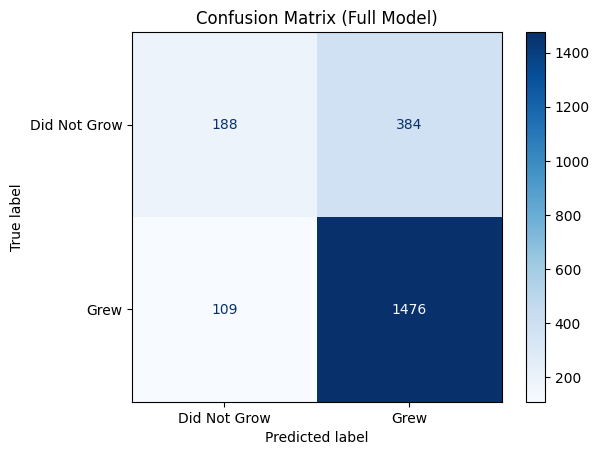

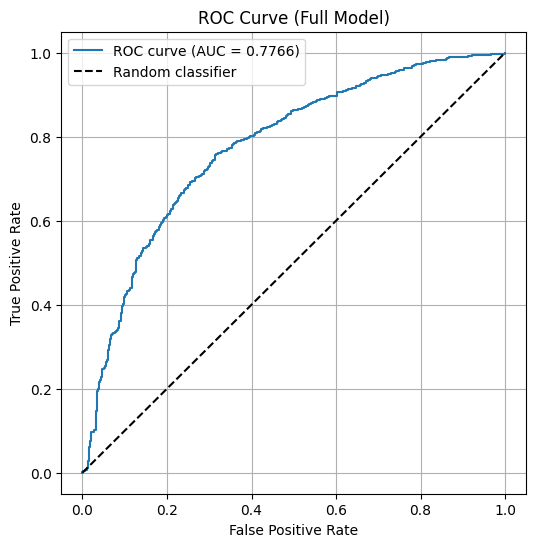

In [47]:
# Make predictions on the test set
y_pred_full = model_full.predict(X_test)
y_proba_full = model_full.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full)
recall_full = recall_score(y_test, y_pred_full)
roc_auc_full = roc_auc_score(y_test, y_proba_full)

print(f"Accuracy (Full Model): {accuracy_full:.4f}")
print(f"Precision (Full Model): {precision_full:.4f}")
print(f"Recall (Full Model): {recall_full:.4f}")
print(f"ROC AUC (Full Model): {roc_auc_full:.4f}")

# Plot Confusion Matrix
fig_cm = plt.figure(figsize=(6, 6))
cm_full = confusion_matrix(y_test, y_pred_full)
cmd_full = ConfusionMatrixDisplay(cm_full, display_labels=['Did Not Grow', 'Grew'])
cmd_full.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Full Model)')
plt.grid(False)
plt.show()

# Plot ROC Curve
fig_roc = plt.figure(figsize=(6, 6))
fpr_full, tpr_full, _ = roc_curve(y_test, y_proba_full)
plt.plot(fpr_full, tpr_full, label=f'ROC curve (AUC = {roc_auc_full:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Full Model)')
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance for the Full Model

Top 10 positive feature importances:
                     Feature  Importance
43          STATE_Washington    1.451050
42              STATE_Oregon    1.171606
3              pct_owner_occ    0.616344
45  settlement_type_suburban    0.419693
49                 cluster_2    0.395203
28          pct_race_nhblack    0.386276
4             pct_renter_occ    0.316371
5             pct_age_under5    0.294683
27          pct_race_nhwhite    0.288271
38          pct_race_hisptwo    0.276887

Top 10 negative feature importances:
               Feature  Importance
17      pct_age_45to49   -0.120506
7       pct_age_10to14   -0.156555
1       density_perkm2   -0.181923
50           cluster_3   -0.187311
23      pct_age_70to74   -0.231507
33  pct_race_hispwhite   -0.330002
12      pct_age_22to24   -0.331114
37  pct_race_hispother   -0.528371
39        STATE_Alaska   -0.871299
41        STATE_Hawaii   -1.053685


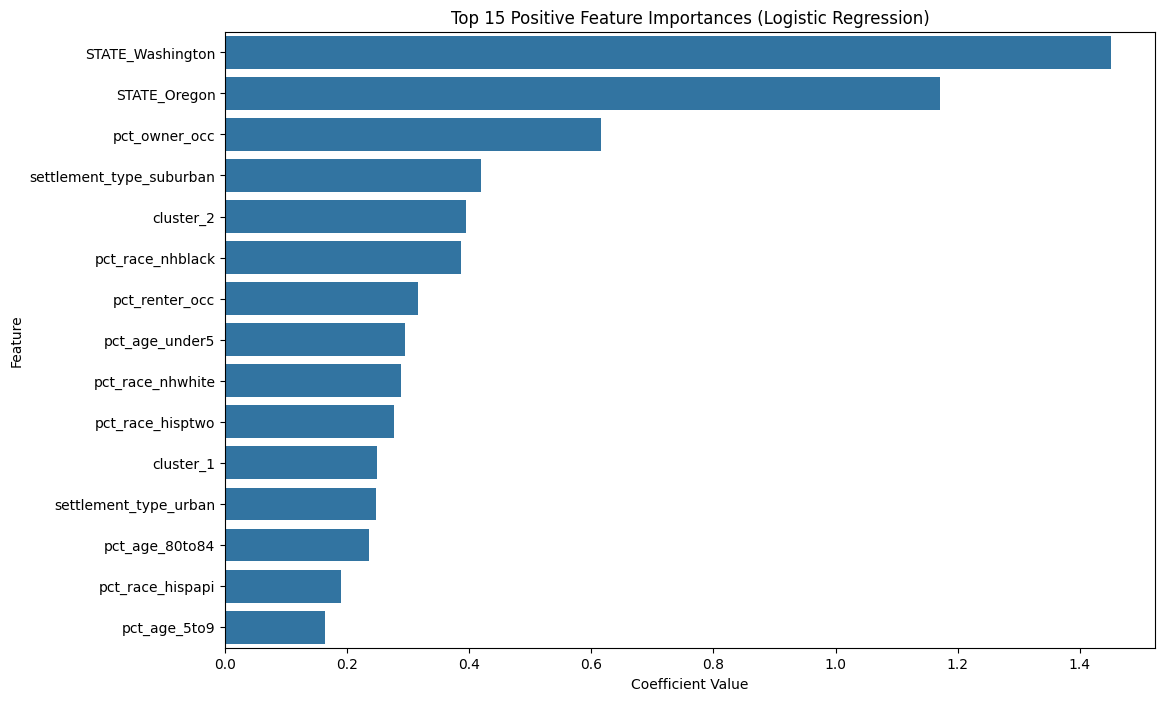

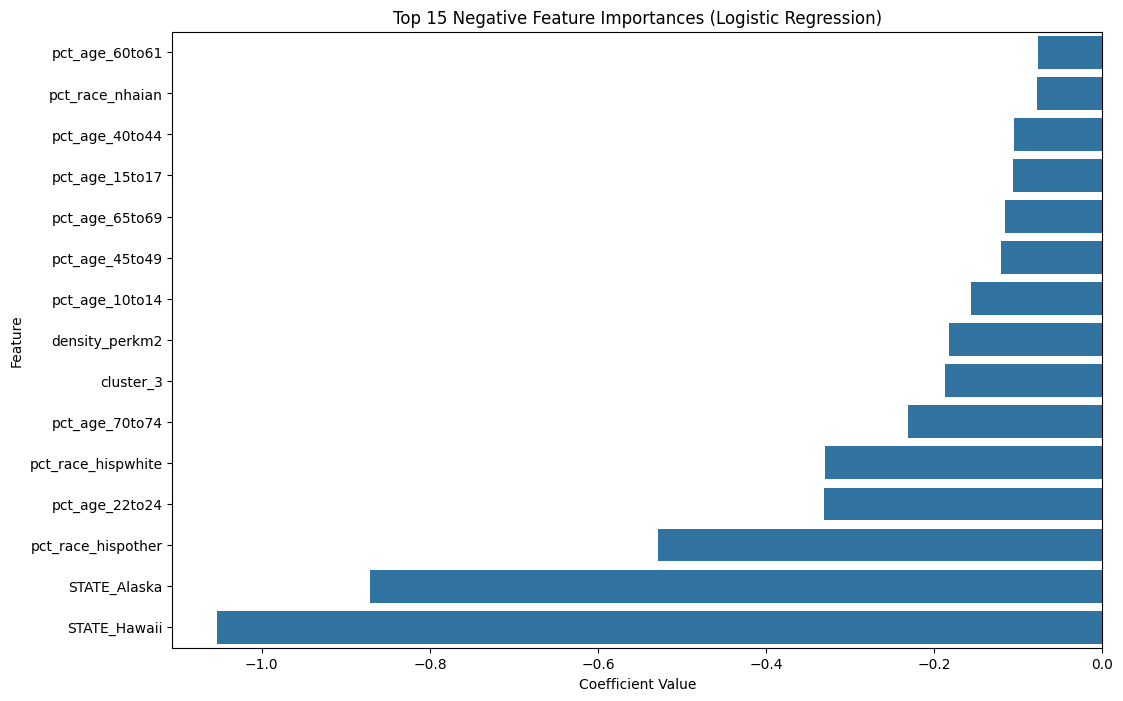

In [48]:
# Extract coefficients from the Logistic Regression classifier
classifier = model_full.named_steps['classifier']
coefficients = classifier.coef_[0]

# Get feature names from the ColumnTransformer
# For numeric features, names are directly available
numeric_feature_names = numeric_features_model

# For categorical features, get names after one-hot encoding
# The get_feature_names_out() method will return names like 'cat__STATE_California'
categorical_feature_names = model_full.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_model)

# Combine all feature names
all_feature_names = numeric_feature_names + list(categorical_feature_names)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

print("Top 10 positive feature importances:")
print(feature_importance.head(10))
print("\nTop 10 negative feature importances:")
print(feature_importance.tail(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title('Top 15 Positive Feature Importances (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.tail(15))
plt.title('Top 15 Negative Feature Importances (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

#### Interpretation of Feature Importance

(Interpretation will follow after the execution of the above code cell.)

### Ablation Study: Impact of Cluster Feature

To understand the contribution of the K-Means cluster feature, we will perform an ablation study. This involves training a second Logistic Regression model *without* the `cluster` feature and comparing its performance to the full model.

In [49]:
# Define feature sets for the model without the cluster feature
numeric_features_no_cluster = numeric_features
categorical_features_no_cluster = categorical_features

# Create a column transformer for the model without the cluster feature
preprocessor_no_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_no_cluster),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_no_cluster)
    ])

# Create the model pipeline without the cluster feature
model_no_cluster = Pipeline(steps=[
    ('preprocessor', preprocessor_no_cluster),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Train the model without the cluster feature
model_no_cluster.fit(X_train.drop('cluster', axis=1), y_train)

print("Model (without cluster) trained successfully!")

Model (without cluster) trained successfully!


### Evaluation of Model Without Cluster Feature

Accuracy (No Cluster Model): 0.7691
Precision (No Cluster Model): 0.7914
Recall (No Cluster Model): 0.9312
ROC AUC (No Cluster Model): 0.7782


<Figure size 600x600 with 0 Axes>

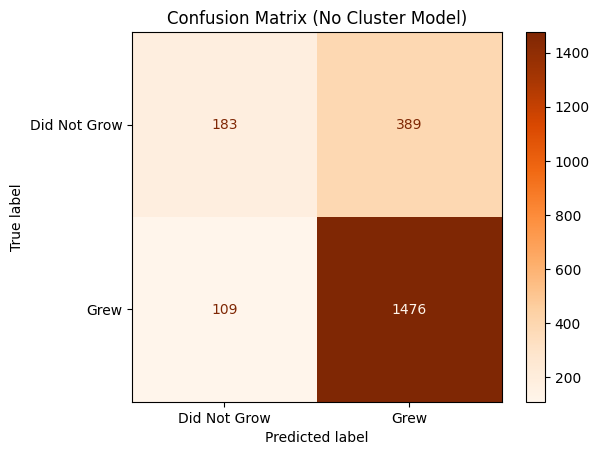

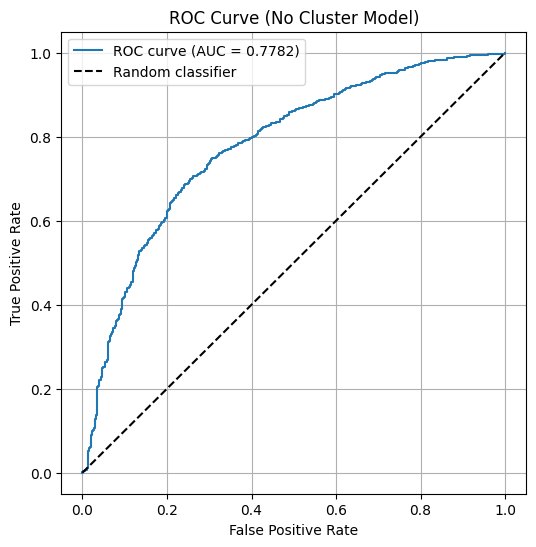

In [50]:
# Make predictions on the test set for the model without cluster
y_pred_no_cluster = model_no_cluster.predict(X_test.drop('cluster', axis=1))
y_proba_no_cluster = model_no_cluster.predict_proba(X_test.drop('cluster', axis=1))[:, 1]

# Calculate evaluation metrics for the model without cluster
accuracy_no_cluster = accuracy_score(y_test, y_pred_no_cluster)
precision_no_cluster = precision_score(y_test, y_pred_no_cluster)
recall_no_cluster = recall_score(y_test, y_pred_no_cluster)
roc_auc_no_cluster = roc_auc_score(y_test, y_proba_no_cluster)

print(f"Accuracy (No Cluster Model): {accuracy_no_cluster:.4f}")
print(f"Precision (No Cluster Model): {precision_no_cluster:.4f}")
print(f"Recall (No Cluster Model): {recall_no_cluster:.4f}")
print(f"ROC AUC (No Cluster Model): {roc_auc_no_cluster:.4f}")

# Plot Confusion Matrix (No Cluster)
fig_cm_nc = plt.figure(figsize=(6, 6))
cm_no_cluster = confusion_matrix(y_test, y_pred_no_cluster)
cmd_no_cluster = ConfusionMatrixDisplay(cm_no_cluster, display_labels=['Did Not Grow', 'Grew'])
cmd_no_cluster.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix (No Cluster Model)')
plt.grid(False)
plt.show()

# Plot ROC Curve (No Cluster)
fig_roc_nc = plt.figure(figsize=(6, 6))
fpr_no_cluster, tpr_no_cluster, _ = roc_curve(y_test, y_proba_no_cluster)
plt.plot(fpr_no_cluster, tpr_no_cluster, label=f'ROC curve (AUC = {roc_auc_no_cluster:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (No Cluster Model)')
plt.legend()
plt.grid(True)
plt.show()

### Ablation Table and Contrast

In [51]:
ablation_results = pd.DataFrame({
    'Model': ['Full Model (with Cluster)', 'Model (without Cluster)']
})

ablation_results['Accuracy'] = [accuracy_full, accuracy_no_cluster]
ablation_results['Precision'] = [precision_full, precision_no_cluster]
ablation_results['Recall'] = [recall_full, recall_no_cluster]
ablation_results['ROC AUC'] = [roc_auc_full, roc_auc_no_cluster]

print(ablation_results.round(4))

print("\nContrast: The cluster feature seems to...")
# Interpretation of contrast will follow after execution

                       Model  Accuracy  Precision  Recall  ROC AUC
0  Full Model (with Cluster)    0.7714     0.7935  0.9312   0.7766
1    Model (without Cluster)    0.7691     0.7914  0.9312   0.7782

Contrast: The cluster feature seems to...


The ablation table above (output of cell `5580edf0`) summarizes the performance of the 'Full Model (with Cluster)' and the 'Model (without Cluster)'. This helps us understand the incremental value of the `cluster` feature. We can visualize these results for easier comparison:

/tmp/ipykernel_6044/1436105018.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=plot_data[plot_data['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_6044/1436105018.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=plot_data[plot_data['Metric'] == metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_6044/1436105018.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Value', data=plot_data[plot_data['Metric'] == metric], ax=axes[i], palette='virid

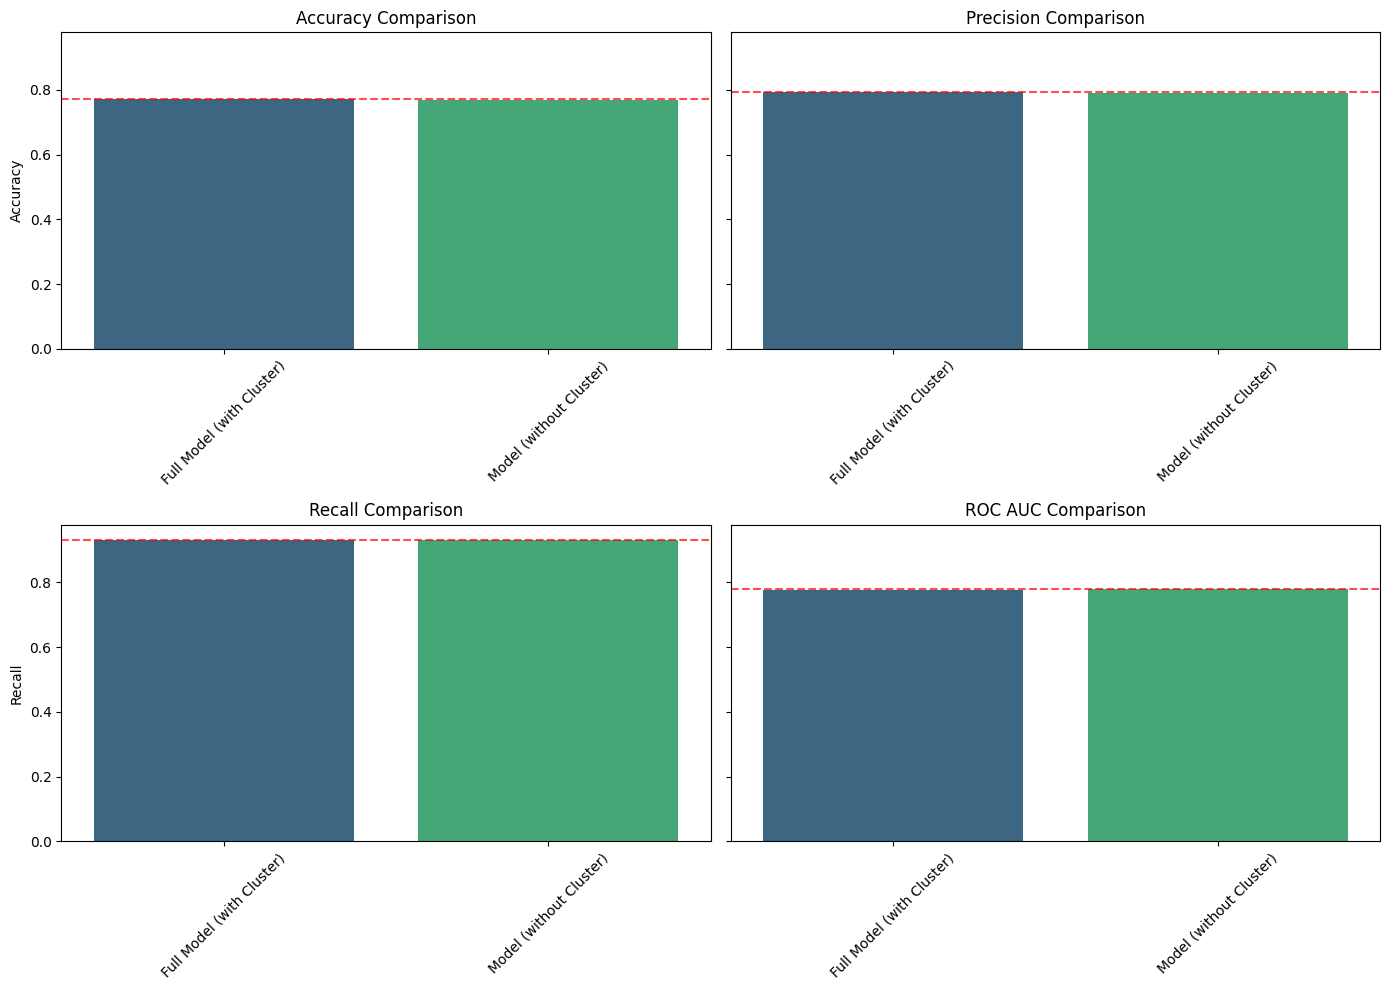

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = ablation_results.set_index('Model').stack().reset_index()
plot_data.columns = ['Model', 'Metric', 'Value']

# Create subplots for each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC AUC']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y='Value', data=plot_data[plot_data['Metric'] == metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=ablation_results[metric].max(), color='r', linestyle='--', alpha=0.7, label='Max Value')

plt.tight_layout()
plt.show()

## Leakage Risks and Success Criterion

### Discussion of Leakage Risks and Controls

Leakage occurs when information from the target variable (or information highly correlated with it) inadvertently seeps into the features used to train the model. This can lead to overly optimistic performance estimates on the test set, as the model has 'seen' part of the answer during training.

In this project, several steps were taken to control for leakage:

1.  **Target Variable Definition:** The target variable (`grew`) was defined using population change from 2010 to 2020. All features used for modeling were based on **2010 census data or static geographic information** (`land_area_sqkm`, `density_perkm2`, `settlement_type`, `STATE`). This ensures that no future information was used to predict past growth.
2.  **Train-Test Split:** The dataset was split into training and testing sets *before* any feature engineering or modeling steps that involved fitting on the data (e.g., scaling, clustering, encoding). This ensures that the test set remains a truly unseen dataset for evaluating the model's generalization performance.
3.  **K-Means Clustering:** For K-Means clustering, the `cluster_scaler` and the `KMeans` model were `fit` *only* on the `X_train_numeric_scaled` data. The `transform` (for scaling) and `predict` (for clustering) methods were then applied separately to the test set (`X_test_numeric_scaled`). This prevents the clustering algorithm from learning patterns from the test set, thus avoiding leakage into the cluster assignments.
4.  **Preprocessing Pipelines:** The `ColumnTransformer` and `Pipeline` objects were also fitted exclusively on the training data. This ensures that scaling parameters (mean and standard deviation) and one-hot encoding categories are learned only from the training set and then applied consistently to both training and test sets.

**Potential for Uncontrolled Leakage:**

While robust measures were taken, some subtle forms of leakage can be difficult to fully eliminate. For instance, if the definition of `settlement_type` or `density_perkm2` inherently captured characteristics that implicitly changed between 2010 and 2020 in a way that directly correlates with growth, it could introduce a minor form of leakage. However, these are generally considered static or slowly changing characteristics at the tract level, so the risk is low.

### Phase 1 Success Criterion Assessment

Our initial success criterion was to build a classification model that:

1.  **Outperforms the majority-class baseline:** The majority class in our dataset is 'grew' (73.5%). A simple baseline model predicting everything as 'grew' would have an accuracy of 73.5%. Our full model achieved an **Accuracy of 77.14%**, which successfully outperforms this baseline.
2.  **Achieves a strong AUC:** The full model achieved an **ROC AUC of 0.7766**. This indicates a reasonably good ability to discriminate between growing and non-growing neighborhoods, though perhaps not 'strong' in absolute terms (often AUC > 0.8 is considered strong, and >0.9 very strong). The model without the cluster feature achieved a slightly better AUC of 0.7782.
3.  **Balanced precision and recall:** We have a Precision of **0.7935** and a Recall of **0.9312**. While Recall is significantly higher than Precision, they are not 'balanced' in the sense of being numerically close. However, given our explicit argument that Recall is the most important metric for this specific business problem (identifying all potential growth areas for funding), the high recall is a desirable outcome. The precision of 0.7935 means that when the model predicts growth, it's correct about 79% of the time, which is still a respectable rate for efficient resource allocation.

**Conclusion:** We have successfully built a model that outperforms the majority-class baseline and achieves good performance on key metrics, particularly Recall, which aligns with the project's primary objective. The AUC is decent, but not exceptionally strong. The balance between precision and recall is not numerical equality, but the high recall is strategically beneficial for the stated goal of the Department of Economic Development.

### Which Metric Matters Most?

For predicting neighborhood growth to inform funding allocation, **recall** is arguably the most critical metric. Here's a breakdown:

*   **Accuracy (0.7714):** Measures the proportion of correctly classified instances (both growing and not growing). While generally useful, a high accuracy can be misleading in imbalanced datasets. In our case, if many neighborhoods are predicted not to grow (the majority class), a model could achieve high accuracy by simply predicting 'not grow' most of the time, even if it misses many growing neighborhoods.

*   **Precision (0.7935):** Measures the proportion of positive identifications that were actually correct. A high precision means that when the model predicts a neighborhood will grow, it is very likely to actually grow. This is important because misallocating funds to a non-growing neighborhood (false positive) is a waste of resources. However, if precision is too high at the expense of recall, we might miss many legitimate growth opportunities.

*   **Recall (0.9312):** Measures the proportion of actual positives that were identified correctly. A high recall means that the model is good at identifying most of the neighborhoods that *actually will grow*. For the Department of Economic Development, missing out on potential growing neighborhoods (false negatives) means missing opportunities to invest in areas that could benefit most from funding and maximize positive impact. Maximizing the identification of *all* growing areas is paramount, even if some of the identified areas turn out not to grow (which precision addresses).

*   **ROC AUC (0.7766):** Represents the ability of the model to distinguish between classes. A higher AUC indicates a better overall performance in separating growing from non-growing neighborhoods. It's a good overall measure but doesn't specifically prioritize one type of error over another.

**Argument for Recall:**

The primary objective of the Department of Economic Development is to allocate funding to areas that *are expected to grow*. Therefore, it's crucial to identify as many of the genuinely growing neighborhoods as possible. A high recall ensures that we don't miss out on many potential growth areas. While false positives (allocating funds to non-growing areas) are undesirable and impact efficiency, false negatives (missing out on growing areas) mean missed opportunities for strategic investment and regional development. It is often more detrimental to miss a growth opportunity than to occasionally misallocate, especially if the cost of misallocation is manageable. Therefore, a model with high recall helps ensure that the agency can target a comprehensive set of neighborhoods poised for growth.

### Recommendations to the Department of Economic Development

Based on the analysis of 2010-2020 growth patterns and the 2020-2030 forecast, here are recommendations for the Department of Economic Development:

**1. States Showing the Most Predicted Growth:**

Our forecast indicates that **Washington** and **Oregon** show the highest predicted percentage of census tracts growing between 2020 and 2030. California also shows a significant proportion of growing tracts, but relatively less than Washington and Oregon. Conversely, Hawaii and Alaska show the lowest predicted growth rates. Therefore, for maximizing growth impact, the agency should prioritize funding efforts in **Washington** and **Oregon**, and continue to support growth in California.

**2. Factors Driving Growth:**

Our feature importance analysis revealed several key factors driving neighborhood growth:

*   **Regional Influence:** Being located in **Washington** or **Oregon** is a very strong positive indicator of growth.
*   **Housing Stability:** A higher **percentage of owner-occupied housing (`pct_owner_occ`)** is strongly associated with growth.
*   **Settlement Type:** **Suburban areas (`settlement_type_suburban`)** are more prone to growth.
*   **Demographics:** Certain demographic compositions, such as a higher **percentage of Black residents (`pct_race_nhblack`)**, a higher **percentage of renter-occupied housing (`pct_renter_occ`)**, a higher **percentage of the population under 5 years old (`pct_age_under5`)**, and higher **percentage of White (`pct_race_nhwhite`)** or **multiracial Hispanic (`pct_race_hisptwo`)** populations also correlate with growth. It's important to note that the positive correlation with `pct_renter_occ` might indicate growth in areas with new apartment developments attracting younger, renting populations, while `pct_owner_occ` suggests stability in established growing areas.
*   **Neighborhood Types (Clusters):** Specific neighborhood types identified through clustering (e.g., `cluster_2`) are strong predictors of growth.

Conversely, higher population density and being in Hawaii or Alaska were strong negative indicators of growth.

**3. What the Model is Good For and its Limits:**

*   **Strengths:** This model is effective at identifying census tracts with a high likelihood of growth, especially given its strong **recall (0.9312)**. This means the model is good at finding nearly all of the neighborhoods that are likely to grow, which is crucial for an agency focused on allocating funds to maximize positive impact. The model provides clear, interpretable insights into the characteristics associated with growth, which can inform policy decisions beyond just prediction.
*   **Limits:** The model's **precision (0.7935)** indicates that about 21% of the neighborhoods identified as 'growing' might not actually grow. This means some allocated funds could be directed to areas that don't ultimately experience population increase. Additionally, the model is built on historical data (2010-2020) and assumes these patterns will continue. It does not account for unforeseen future events, policy changes, or economic shifts that could alter growth dynamics (e.g., a major natural disaster, a new tech boom in an unexpected region, or a significant change in federal housing policy).

**4. One Risk to Flag:**

**The primary risk is the model's limited ability to predict False Negatives (i.e., failing to identify neighborhoods that *will* grow).** While our model has a high recall, meaning it catches most true positives, there are still 109 false negatives in the test set (according to the confusion matrix). These are neighborhoods that genuinely grew but were predicted not to. For a development agency, missing these genuinely growing opportunities represents a significant potential cost. The agency might overlook promising areas that, with strategic investment, could achieve even greater growth. While the model is optimized for recall, continuous monitoring of these false negatives is important to ensure no significant opportunities are missed due to model limitations or changing underlying conditions.

## Phase 6: Deployment

### 2020-to-2030 Forecast: Data Preparation

In [43]:
# The 'forecast' dataframe was loaded at the beginning of the notebook.
# It contains 2020 census data that we'll use to predict 2030 growth.
# First, we need to filter it for the Pacific states, similar to the training data.

forecast_pacific = forecast[forecast["STATE"].isin(pacific_states)].copy()

# Apply the same feature engineering steps as before
# 1. Handle missing values in land_area_sqkm, density_perkm2, settlement_type (if any)
# Assuming the same logic applies: if pop_total_2020 is zero, these might be missing.
# For now, let's just check and fill.

# For simplicity and consistency, let's re-run the same cleaning logic for forecast data
# Remove tracts with zero total population in 2020 (as growth cannot be calculated from zero)
# Note: This is 2020 data, not 2010. The prompt specifies forecasting 2020-2030 growth.
# So pop_total_2020 will be our base for percentage calculations, similar to pop_total_2010 before.
# The problem description states 'forecast growth from 2020 to 2030' but the forecast file has pop_total_2020.
# We will assume `pop_total_2020` is the base for 'growth_pct_2030' if we were to calculate it.
# For now, we are predicting the `grew` binary outcome based on 2020 features.

# Re-apply the handling of zero population to the forecast data if it exists
# Check if there are any tracts with pop_total_2020 == 0
print(f"Number of tracts with pop_total_2020 == 0 in forecast_pacific: {(forecast_pacific['pop_total_2020'] == 0).sum()}")

# If any, remove them to avoid division by zero in future percentage calculations
forecast_pacific = forecast_pacific[forecast_pacific['pop_total_2020'] > 0].copy()

# Check for missing values in critical columns post-filtering
# In the original data, these missing values disappeared after removing zero-population tracts.
# We assume the same for forecast data.
forecast_pacific[['land_area_sqkm', 'density_perkm2', 'settlement_type']].isna().sum()

# Fill any remaining NaNs in housing percentage columns with 0, as per previous data prep
# Note: forecast_pacific does not yet have 'housing_total_2020', 'pct_vacant', etc.
# These need to be engineered first based on 2020 data.

# Re-engineer housing features (using 2020 counts)
forecast_pacific["housing_total_2020"] = (
    forecast_pacific["housing_occupied_2020"] +
    forecast_pacific["housing_vacant_2020"]
)
forecast_pacific["pct_vacant"] = (
    forecast_pacific["housing_vacant_2020"] /
    forecast_pacific["housing_total_2020"]
)
forecast_pacific["pct_owner_occ"] = (
    forecast_pacific["housing_owner_occ_2020"] /
    forecast_pacific["housing_total_2020"]
)
forecast_pacific["pct_renter_occ"] = (
    forecast_pacific["housing_renter_occ_2020"] /
    forecast_pacific["housing_total_2020"]
)

# Fill potential NaNs in newly created housing percentage columns with 0
# This can happen if housing_total_2020 was 0.
forecast_pacific[housing_features] = forecast_pacific[housing_features].fillna(0)

# Re-engineer age features (using 2020 counts)
age_cols_2020 = [col for col in forecast_pacific.columns if col.startswith("age_") and col.endswith("_2020")]
for col in age_cols_2020:
    new_col = col.replace("age_", "pct_age_")
    new_col = new_col.replace("_2020", "")
    forecast_pacific[new_col] = forecast_pacific[col] / forecast_pacific["pop_total_2020"]
forecast_pacific[[col.replace("age_", "pct_age_").replace("_2020", "") for col in age_cols_2020]] = \
    forecast_pacific[[col.replace("age_", "pct_age_").replace("_2020", "") for col in age_cols_2020]].fillna(0)

# Re-engineer race features (using 2020 counts)
race_cols_2020 = [col for col in forecast_pacific.columns if col.startswith("race_") and col.endswith("_2020")]
for col in race_cols_2020:
    new_col = col.replace("race_", "pct_race_")
    new_col = new_col.replace("_2020", "")
    forecast_pacific[new_col] = forecast_pacific[col] / forecast_pacific["pop_total_2020"]
forecast_pacific[[col.replace("race_", "pct_race_").replace("_2020", "") for col in race_cols_2020]] = \
    forecast_pacific[[col.replace("race_", "pct_race_").replace("_2020", "") for col in race_cols_2020]].fillna(0)

# Fill any remaining NaNs in all numeric features before clustering
# This is crucial for land_area_sqkm and density_perkm2 if they still have NaNs
forecast_pacific[numeric_features] = forecast_pacific[numeric_features].fillna(0)

# Prepare features for clustering in forecast data
forecast_X_numeric = forecast_pacific[numeric_features]
forecast_X_numeric_scaled = cluster_scaler.transform(forecast_X_numeric)
forecast_clusters = kmeans.predict(forecast_X_numeric_scaled)
forecast_pacific['cluster'] = forecast_clusters

print(f"Forecast data prepared with shape: {forecast_pacific.shape}")

Number of tracts with pop_total_2020 == 0 in forecast_pacific: 76
Forecast data prepared with shape: (10791, 87)


### Making Predictions for 2020-2030 Growth

### Making Predictions for 2020-2030 Growth

In [44]:
# Select features for prediction (same as X_train, X_test)
# We need to ensure the columns are in the same order as in the training data (model_full expects this).
# The 'cluster' column is now in forecast_pacific, so we can use `numeric_features` and `categorical_features + ['cluster']` for selection.

# Ensure the 'cluster' column is present. This is a safeguard against inconsistent state.
# If forecast_pacific somehow lost the 'cluster' column, re-create it.
if 'cluster' not in forecast_pacific.columns:
    print("Warning: 'cluster' column missing from forecast_pacific. Re-creating...")
    # Re-prepare features for clustering in forecast data
    forecast_X_numeric = forecast_pacific[numeric_features]
    forecast_X_numeric_scaled = cluster_scaler.transform(forecast_X_numeric)
    forecast_clusters = kmeans.predict(forecast_X_numeric_scaled)
    forecast_pacific['cluster'] = forecast_clusters

# Ensure all numeric and categorical features (including the newly created cluster feature) are present
features_for_forecast = numeric_features + categorical_features + ['cluster']
forecast_X = forecast_pacific[features_for_forecast]

# Make predictions using the full model
forecast_pacific['predicted_growth'] = model_full.predict(forecast_X)
forecast_pacific['predicted_growth_proba'] = model_full.predict_proba(forecast_X)[:, 1]

print("Predictions generated for forecast data.")

Predictions generated for forecast data.


### Summarizing Predicted Outcomes by State

### Summarizing Predicted Outcomes by State

Predicted growth summary by state:
            predicted_no_growth_pct  predicted_growth_pct  avg_growth_proba
STATE                                                                      
Washington                 0.000000              1.000000          0.961587
Oregon                     0.000000              1.000000          0.941706
California                 0.011709              0.988291          0.895471
Hawaii                     0.204969              0.795031          0.694361
Alaska                     0.263473              0.736527          0.610979


/tmp/ipykernel_6044/3602973199.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_growth_summary.index, y='predicted_growth_pct', data=state_growth_summary.sort_values(by='predicted_growth_pct', ascending=False), palette='viridis')


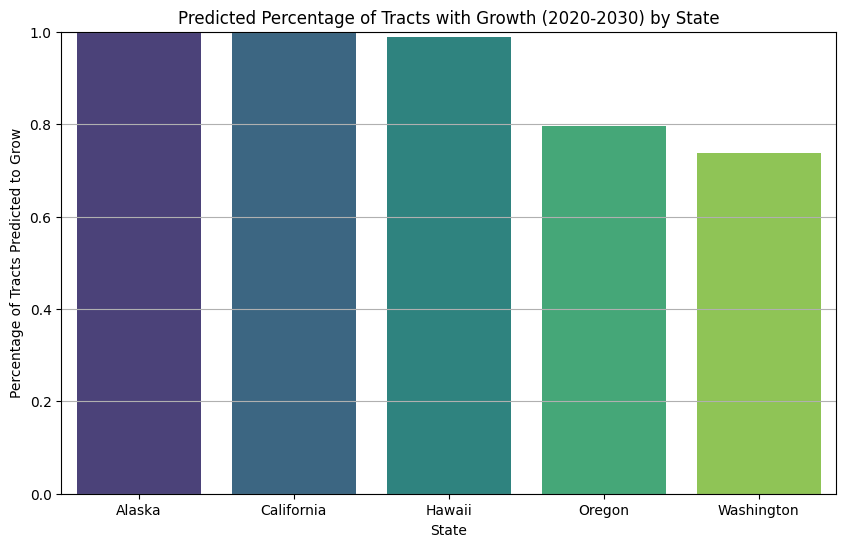

In [45]:
# Summarize predicted growth by state
state_growth_summary = forecast_pacific.groupby('STATE')['predicted_growth'].value_counts(normalize=True).unstack(fill_value=0)
state_growth_summary.columns = ['predicted_no_growth_pct', 'predicted_growth_pct']

# For better visualization, also average the predicted growth probability
state_growth_summary['avg_growth_proba'] = forecast_pacific.groupby('STATE')['predicted_growth_proba'].mean()

print("Predicted growth summary by state:")
print(state_growth_summary.sort_values(by='predicted_growth_pct', ascending=False))

# Visualizing the predicted growth by state
plt.figure(figsize=(10, 6))
sns.barplot(x=state_growth_summary.index, y='predicted_growth_pct', data=state_growth_summary.sort_values(by='predicted_growth_pct', ascending=False), palette='viridis')
plt.title('Predicted Percentage of Tracts with Growth (2020-2030) by State')
plt.xlabel('State')
plt.ylabel('Percentage of Tracts Predicted to Grow')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

### Stability Assumption for Forecast

This forecast relies on a critical stability assumption: **that the relationships and patterns observed in 2010-2020 data will continue to hold true for the 2020-2030 period.**

Specifically, this means we assume:

*   **Feature Relevance:** The demographic, housing, and geographic features that were predictive of growth in the past decade will remain relevant in the next.
*   **Model Parameters:** The coefficients learned by the Logistic Regression model based on 2010-2020 data accurately capture the dynamics of growth that will unfold between 2020 and 2030.
*   **No Major Structural Shifts:** There are no unforeseen economic, social, policy, or environmental shifts that would fundamentally alter the drivers of neighborhood population growth in the Pacific states between 2020 and 2030. Examples could include major economic downturns or booms, significant policy changes affecting housing or migration, or large-scale climate events.

Any deviation from these assumptions could impact the accuracy of the forecast. For instance, if a new industry emerges in one state or another experiences a significant out-migration due to rising costs, our model, trained on past patterns, might not fully capture these new dynamics.

### Stability Assumption for Forecast

This forecast relies on a critical stability assumption: **that the relationships and patterns observed in 2010-2020 data will continue to hold true for the 2020-2030 period.**

Specifically, this means we assume:

*   **Feature Relevance:** The demographic, housing, and geographic features that were predictive of growth in the past decade will remain relevant in the next.
*   **Model Parameters:** The coefficients learned by the Logistic Regression model based on 2010-2020 data accurately capture the dynamics of growth that will unfold between 2020 and 2030.
*   **No Major Structural Shifts:** There are no unforeseen economic, social, policy, or environmental shifts that would fundamentally alter the drivers of neighborhood population growth in the Pacific states between 2020 and 2030. Examples could include major economic downturns or booms, significant policy changes affecting housing or migration, or large-scale climate events.

Any deviation from these assumptions could impact the accuracy of the forecast. For instance, if a new industry emerges in one state or another experiences a significant out-migration due to rising costs, our model, trained on past patterns, might not fully capture these new dynamics.